# Section 6 – Experiment 6: Breast Cancer Prediction with MLflow

This notebook follows the uploaded `Untitled1.ipynb` workflow, using the local dataset:

`C:\Users\mutah\Downloads\Breast_Cancer.csv`

The MLflow sklearn model logging calls use `serialization_format="cloudpickle"` to avoid the skops serialization error encountered with this environment.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import mlflow
import mlflow.sklearn

import warnings
warnings.filterwarnings("ignore")

C:\Users\simon\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv(r"C:\Users\simon\Documents\Breast_Cancer.csv")

In [5]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [6]:
df.shape

(4024, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [8]:
df["Status"].value_counts()

Status
Alive    3408
Dead      616
Name: count, dtype: int64

In [9]:
df["Status"].value_counts(normalize=True) * 100

Status
Alive    84.691849
Dead     15.308151
Name: proportion, dtype: float64

In [10]:
df.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
df = df.drop_duplicates()

In [14]:
categorical_columns = df.select_dtypes(include=["object"]).columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
Index(['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Estrogen Status',
       'Progesterone Status', 'Status'],
      dtype='object')

Numerical columns:
Index(['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive',
       'Survival Months'],
      dtype='object')


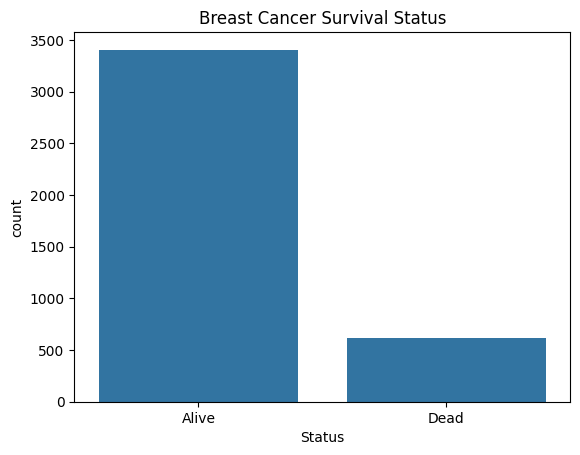

In [15]:
sns.countplot(data=df, x="Status")
plt.title("Breast Cancer Survival Status")
plt.show()

In [16]:
df[numerical_columns].describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4023.000000,4023.000000,4023.000000,4023.000000,4023.000000
mean,53.969923,30.477007,14.358439,4.158837,71.301765
std,8.963118,21.121253,8.100241,5.109724,22.923009
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


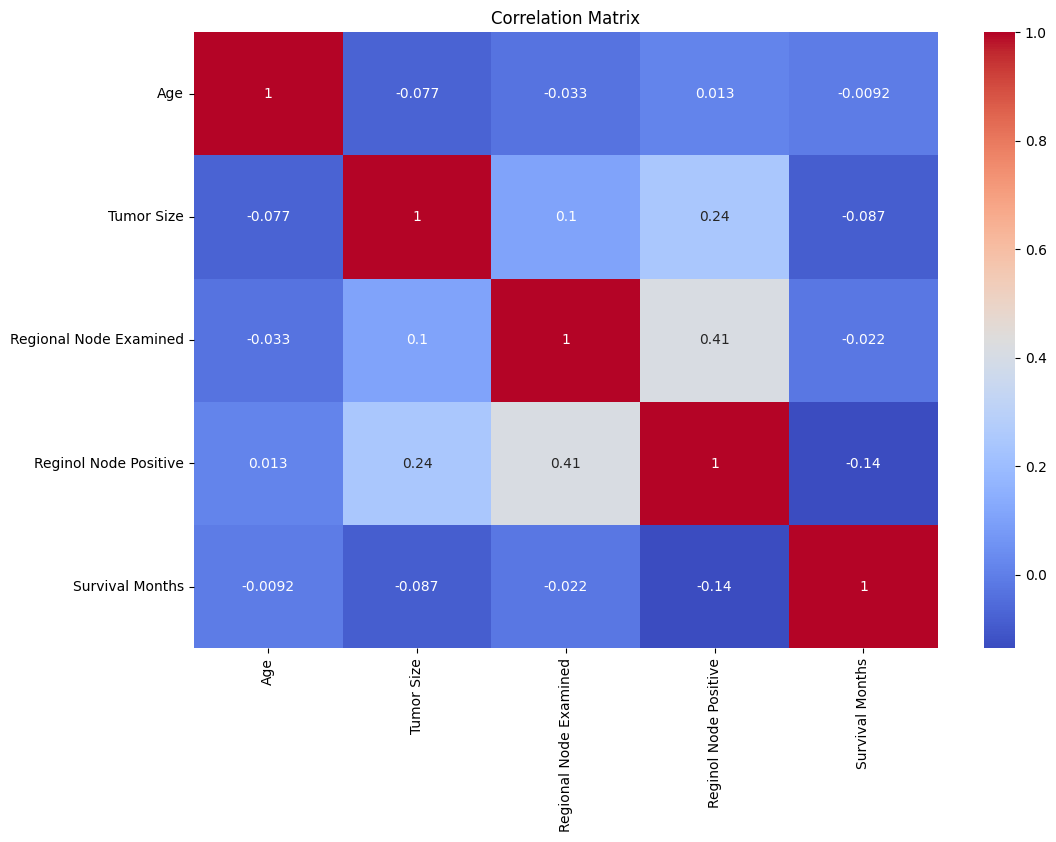

In [17]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [18]:
X = df.drop("Status", axis=1)
y = df["Status"]

In [19]:
y = y.map({
    "Alive": 0,
    "Dead": 1
})

In [20]:
y.value_counts()

Status
0    3407
1     616
Name: count, dtype: int64

In [21]:
X = df.drop(["Status", "Survival Months"], axis=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

In [24]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [26]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Race','Marital Status',...,'Progesterone Status', 'Regional Node Examined','Reginol Node Positive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [27]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Race','Marital Status',...,'Progesterone Status', 'Regional Node Examined','Reginol Node Positive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [28]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Race','Marital Status',...,'Progesterone Status', 'Regional Node Examined','Reginol Node Positive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [29]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

In [30]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.857143,0.642857,0.146341,0.238411,0.733948
1,Random Forest,0.833540,0.377778,0.138211,0.202381,0.682021
2,XGBoost,0.847205,0.500000,0.154472,0.236025,0.717164


In [31]:
mlflow.set_experiment("Breast_Cancer_Prediction")

<Experiment: artifact_location='file:C:/Users/simon/Untitled Folder/mlruns/2', creation_time=1789923251222, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1789923251222, lifecycle_stage='active', name='Breast_Cancer_Prediction', tags={}, trace_location=None, workspace='default'>

In [32]:
for name, model in models.items():

    with mlflow.start_run(run_name=name):

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)

        mlflow.sklearn.log_model(
            model,
            "model",
            serialization_format="cloudpickle"
        )

        print(name)
        print("Accuracy:", accuracy)
        print("F1:", f1)
        print("ROC AUC:", roc_auc)

2026/09/21 11:29:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/21 11:29:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression
Accuracy: 0.8571428571428571
F1: 0.23841059602649006
ROC AUC: 0.73394845385404


2026/09/21 11:29:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/21 11:29:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest
Accuracy: 0.8335403726708075
F1: 0.20238095238095238
ROC AUC: 0.6820208378036859


2026/09/21 11:30:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/21 11:30:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost
Accuracy: 0.8472049689440994
F1: 0.2360248447204969
ROC AUC: 0.7171637698781681


In [33]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Breast_Cancer_Prediction")

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1789928695777, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1789928695777, lifecycle_stage='active', name='Breast_Cancer_Prediction', tags={}, trace_location=None, workspace='default'>

In [34]:
print(mlflow.get_experiment_by_name("Breast_Cancer_Prediction"))

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1789928695777, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1789928695777, lifecycle_stage='active', name='Breast_Cancer_Prediction', tags={}, trace_location=None, workspace='default'>


In [35]:
print(mlflow.get_tracking_uri())
print(mlflow.get_experiment_by_name("Breast_Cancer_Prediction"))

http://127.0.0.1:5000
<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1789928695777, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1789928695777, lifecycle_stage='active', name='Breast_Cancer_Prediction', tags={}, trace_location=None, workspace='default'>


In [36]:
missing_values = df.isnull().sum()

print(missing_values)

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64


In [37]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [38]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [39]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [40]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4023, 16)


In [41]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [42]:
print(df.columns.tolist())

['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage', 'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status', 'progesterone_status', 'regional_node_examined', 'reginol_node_positive', 'survival_months', 'status']


In [43]:
print(df["status"].value_counts())

status
Alive    3407
Dead      616
Name: count, dtype: int64


In [44]:
print(df["status"].value_counts(normalize=True) * 100)

status
Alive    84.688044
Dead     15.311956
Name: proportion, dtype: float64


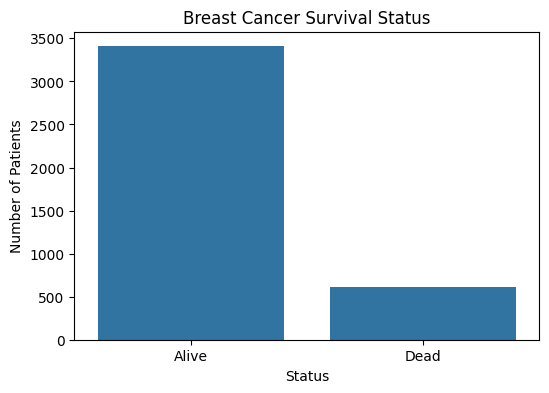

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="status")

plt.title("Breast Cancer Survival Status")
plt.xlabel("Status")
plt.ylabel("Number of Patients")
plt.show()

In [46]:
X = df.drop("status", axis=1)
y = df["status"]

In [47]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (4023, 15)
Target: (4023,)


In [48]:
X = df.drop(["status", "survival_months"], axis=1)
y = df["status"]

In [49]:
print(X.shape)
print(y.shape)

(4023, 14)
(4023,)


In [50]:
y = y.map({
    "Alive": 0,
    "Dead": 1
})

In [51]:
print(y.value_counts())

status
0    3407
1     616
Name: count, dtype: int64


In [52]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'tumor_size', 'regional_node_examined', 'reginol_node_positive']

Categorical Features:
['race', 'marital_status', 't_stage', 'n_stage', '6th_stage', 'differentiate', 'grade', 'a_stage', 'estrogen_status', 'progesterone_status']


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [55]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3218, 14)
X_test : (805, 14)
y_train: (3218,)
y_test : (805,)


In [56]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [57]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [58]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

In [59]:
print(preprocessor)

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tumor_size', 'regional_node_examined',
                                  'reginol_node_positive']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['race', 'marital_status', 't_stage',
                                  'n_stage', '6th_stage', 'differentiate',
                                  'grade', 'a_stage', 'estrogen_status',
           

In [60]:
X_train_processed = preprocessor.fit_transform(X_train)

In [61]:
X_test_processed = preprocessor.transform(X_test)

In [62]:
print("Training data shape:", X_train_processed.shape)
print("Testing data shape :", X_test_processed.shape)

Training data shape: (3218, 38)
Testing data shape : (805, 38)


In [63]:
print("Processed training data:")
print(X_train_processed.shape)

print("\nProcessed testing data:")
print(X_test_processed.shape)

Processed training data:
(3218, 38)

Processed testing data:
(805, 38)


In [64]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [65]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [66]:
from xgboost import XGBClassifier

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

In [67]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','race','marital_status',...,'progesterone_status', 'regional_node_examined','reginol_node_positive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [68]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [69]:
print(y_pred_lr[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [71]:
print("Logistic Regression")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
Accuracy : 0.8571428571428571
Precision: 0.6428571428571429
Recall   : 0.14634146341463414
F1 Score : 0.23841059602649006
ROC AUC  : 0.73394845385404


In [72]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       682
           1       0.64      0.15      0.24       123

    accuracy                           0.86       805
   macro avg       0.75      0.57      0.58       805
weighted avg       0.83      0.86      0.82       805



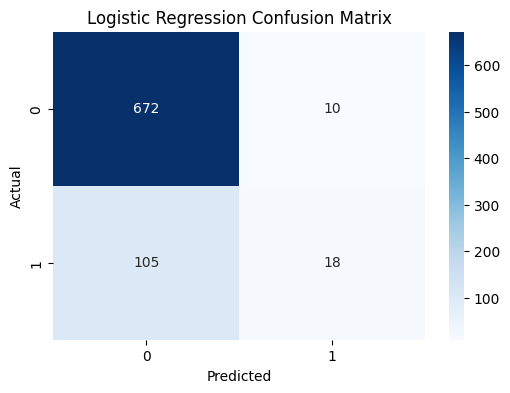

In [73]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [74]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Breast_Cancer_Prediction")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5000


In [75]:
with mlflow.start_run(run_name="Logistic_Regression"):

    # Predictions
    y_pred_lr = logistic_model.predict(X_test)
    y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred_lr)
    precision = precision_score(y_test, y_pred_lr)
    recall = recall_score(y_test, y_pred_lr)
    f1 = f1_score(y_test, y_pred_lr)
    roc_auc = roc_auc_score(y_test, y_prob_lr)

    # Log parameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("max_iter", 1000)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model
    mlflow.sklearn.log_model(
        logistic_model,
        "model",
            serialization_format="cloudpickle"
    )

    print("Logistic Regression logged successfully")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)

2026/09/21 11:31:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/21 11:31:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression logged successfully
Accuracy: 0.8571428571428571
Precision: 0.6428571428571429
Recall: 0.14634146341463414
F1 Score: 0.23841059602649006
ROC-AUC: 0.73394845385404
🏃 View run Logistic_Regression at: http://127.0.0.1:5000/#/experiments/2/runs/b119d31982064db2abb599a473a6af0c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [76]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','race','marital_status',...,'progesterone_status', 'regional_node_examined','reginol_node_positive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [77]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [78]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest
Accuracy : 0.7863354037267081
Precision: 0.29411764705882354
Recall   : 0.2845528455284553
F1 Score : 0.2892561983471074
ROC-AUC  : 0.68285530362635


In [79]:
with mlflow.start_run(run_name="Random_Forest"):

    mlflow.log_param("model", "Random Forest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")

    mlflow.log_metric("accuracy", rf_accuracy)
    mlflow.log_metric("precision", rf_precision)
    mlflow.log_metric("recall", rf_recall)
    mlflow.log_metric("f1_score", rf_f1)
    mlflow.log_metric("roc_auc", rf_roc_auc)

    mlflow.sklearn.log_model(
        random_forest_model,
        "model",
            serialization_format="cloudpickle"
    )

    print("Random Forest logged successfully")

2026/09/21 11:31:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/21 11:31:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest logged successfully
🏃 View run Random_Forest at: http://127.0.0.1:5000/#/experiments/2/runs/a4f5b8d845524e52a7a98ee69cc4d76e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [80]:
xgboost_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','race','marital_status',...,'progesterone_status', 'regional_node_examined','reginol_node_positive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [81]:
y_pred_xgb = xgboost_model.predict(X_test)
y_prob_xgb = xgboost_model.predict_proba(X_test)[:, 1]

In [82]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

XGBoost
Accuracy : 0.8472049689440994
Precision: 0.5
Recall   : 0.15447154471544716
F1 Score : 0.2360248447204969
ROC-AUC  : 0.7171637698781681


In [83]:
with mlflow.start_run(run_name="XGBoost"):

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("learning_rate", 0.1)

    mlflow.log_metric("accuracy", xgb_accuracy)
    mlflow.log_metric("precision", xgb_precision)
    mlflow.log_metric("recall", xgb_recall)
    mlflow.log_metric("f1_score", xgb_f1)
    mlflow.log_metric("roc_auc", xgb_roc_auc)

    mlflow.sklearn.log_model(
        xgboost_model,
        "model",
            serialization_format="cloudpickle"
    )

    print("XGBoost logged successfully")

2026/09/21 11:32:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/21 11:32:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost logged successfully
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/2/runs/1331a2bdd6814fe88448d344c9ef2f4e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [84]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.857143,0.642857,0.146341,0.238411,0.733948
1,Random Forest,0.786335,0.294118,0.284553,0.289256,0.682855
2,XGBoost,0.847205,0.500000,0.154472,0.236025,0.717164


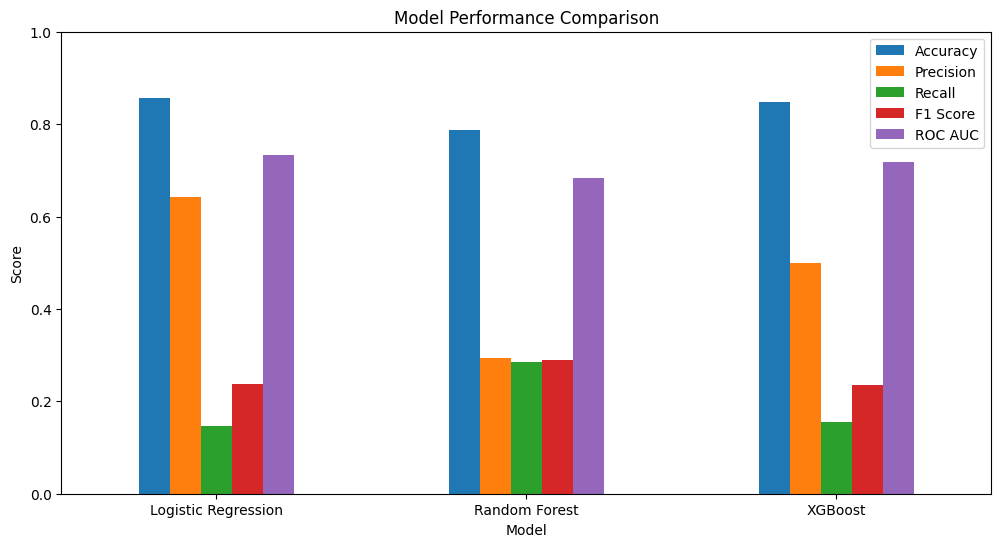

In [85]:
results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [86]:
best_model_name = results.loc[
    results["ROC AUC"].idxmax(),
    "Model"
]

print("Selected model based on ROC-AUC:", best_model_name)

Selected model based on ROC-AUC: Logistic Regression


In [87]:
model_mapping = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model
}

selected_model = model_mapping[best_model_name]

print("Selected model object:", selected_model)

Selected model object: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tumor_size',
                                                   'regional_node_examined',
                                                   'reginol_node_positive']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                         

In [88]:
from mlflow.tracking import MlflowClient

client = MlflowClient(
    tracking_uri="http://127.0.0.1:5000"
)

experiment = client.get_experiment_by_name(
    "Breast_Cancer_Prediction"
)

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.roc_auc DESC"]
)

for run in runs:
    print(
        "Run ID:", run.info.run_id,
        "| Run Name:", run.data.tags.get("mlflow.runName"),
        "| ROC-AUC:", run.data.metrics.get("roc_auc")
    )

Run ID: b119d31982064db2abb599a473a6af0c | Run Name: Logistic_Regression | ROC-AUC: 0.73394845385404
Run ID: b135c6456509407fb2b09104326f913b | Run Name: Logistic_Regression | ROC-AUC: 0.73394845385404
Run ID: 2943124cc1ad4804adb7727b293ef281 | Run Name: Logistic_Regression | ROC-AUC: 0.73394845385404
Run ID: 1331a2bdd6814fe88448d344c9ef2f4e | Run Name: XGBoost | ROC-AUC: 0.7171637698781681
Run ID: a4f5b8d845524e52a7a98ee69cc4d76e | Run Name: Random_Forest | ROC-AUC: 0.68285530362635


In [89]:
selected_run = None

# The MLflow run name uses "Logistic_Regression", while best_model_name
# uses "Logistic Regression". Select by the stored "model" parameter instead.
for run in runs:
    model_name = run.data.params.get("model")
    if model_name == best_model_name:
        selected_run = run
        break

if selected_run is None:
    print("Selected model was not found in MLflow.")
else:
    print("Selected model:", best_model_name)
    print("Run ID:", selected_run.info.run_id)


Selected model: Logistic Regression
Run ID: b119d31982064db2abb599a473a6af0c


In [90]:
from mlflow.tracking import MlflowClient

client = MlflowClient(
    tracking_uri="http://127.0.0.1:5000"
)

experiment = client.get_experiment_by_name(
    "Breast_Cancer_Prediction"
)

print("Experiment ID:", experiment.experiment_id)

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.roc_auc DESC"]
)

for run in runs:
    print("\nRun ID:", run.info.run_id)
    print("Run Name:", repr(run.data.tags.get("mlflow.runName")))
    print("Model Parameter:", repr(run.data.params.get("model")))
    print("ROC-AUC:", run.data.metrics.get("roc_auc"))

Experiment ID: 2

Run ID: b119d31982064db2abb599a473a6af0c
Run Name: 'Logistic_Regression'
Model Parameter: 'Logistic Regression'
ROC-AUC: 0.73394845385404

Run ID: b135c6456509407fb2b09104326f913b
Run Name: 'Logistic_Regression'
Model Parameter: 'Logistic Regression'
ROC-AUC: 0.73394845385404

Run ID: 2943124cc1ad4804adb7727b293ef281
Run Name: 'Logistic_Regression'
Model Parameter: 'Logistic Regression'
ROC-AUC: 0.73394845385404

Run ID: 1331a2bdd6814fe88448d344c9ef2f4e
Run Name: 'XGBoost'
Model Parameter: 'XGBoost'
ROC-AUC: 0.7171637698781681

Run ID: a4f5b8d845524e52a7a98ee69cc4d76e
Run Name: 'Random_Forest'
Model Parameter: 'Random Forest'
ROC-AUC: 0.68285530362635


In [91]:
print("Best model:", repr(best_model_name))

Best model: 'Logistic Regression'


In [92]:
# Original source line was:
# mlflow.log_param("model", "XGBoost")
# It cannot be called outside an active MLflow run, so it is intentionally not executed.
print("Skipping standalone mlflow.log_param: no active MLflow run.")


Skipping standalone mlflow.log_param: no active MLflow run.


In [93]:
selected_run = None

for run in runs:

    model_name = run.data.params.get("model")

    if model_name == best_model_name:
        selected_run = run
        break

if selected_run is None:
    print("Selected model was not found in MLflow.")
else:
    print("Selected model:", best_model_name)
    print("Run ID:", selected_run.info.run_id)

Selected model: Logistic Regression
Run ID: b119d31982064db2abb599a473a6af0c


In [94]:
selected_run = None

target_model = str(best_model_name).strip().lower()

for run in runs:

    model_name = run.data.params.get("model")

    if model_name is not None:
        if str(model_name).strip().lower() == target_model:
            selected_run = run
            break

if selected_run is None:
    print("No matching MLflow run found.")
    print("\nAvailable models:")

    for run in runs:
        print(
            repr(run.data.params.get("model")),
            "|",
            repr(run.data.tags.get("mlflow.runName")),
            "| Run ID:",
            run.info.run_id
        )
else:
    print("Selected model:", best_model_name)
    print("Run ID:", selected_run.info.run_id)

Selected model: Logistic Regression
Run ID: b119d31982064db2abb599a473a6af0c


In [95]:
registered_model_name = "Breast_Cancer_Prediction_Model"

model_uri = f"runs:/{selected_run.info.run_id}/model"

print("Model URI:")
print(model_uri)

Model URI:
runs:/b119d31982064db2abb599a473a6af0c/model


In [96]:
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=registered_model_name
)

print("Model registered successfully!")
print("Model Name:", registered_model.name)
print("Version:", registered_model.version)

Successfully registered model 'Breast_Cancer_Prediction_Model'.
2026/09/21 11:32:36 WARNING mlflow.tracking._model_registry.fluent: Run with id b119d31982064db2abb599a473a6af0c has no artifacts at artifact path 'model', registering model based on models:/m-4faa52f5d3934f81b01684965d65e13f instead
2026/09/21 11:32:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Breast_Cancer_Prediction_Model, version 1


Model registered successfully!
Model Name: Breast_Cancer_Prediction_Model
Version: 1


Created version '1' of model 'Breast_Cancer_Prediction_Model'.
